   cover_limit  relativity  total_exposure   rel_iso  rel_strict_rebased
0         1000    0.812029      329.596167  0.692105            0.676278
1         2000    0.674103     2195.715264  0.692105            0.710092
2         3000    0.694184    23710.683094  0.694184            0.745597
3         4000    0.831176     2337.779603  0.831176            0.812169
4         5000    0.884054     1884.391513  0.884054            0.863838
5         7000    0.899598    48633.237509  0.899598            0.907029
6        10000    0.914665     2163.780972  0.914665            0.952381
7        15000    1.000000    79554.918549  0.997754            1.000000
8        20000    0.757754      744.484600  0.997754            1.050000


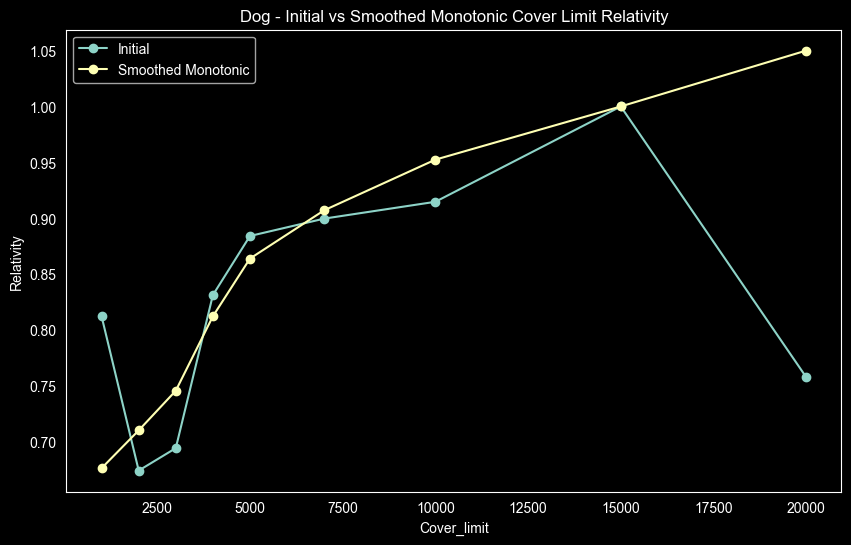

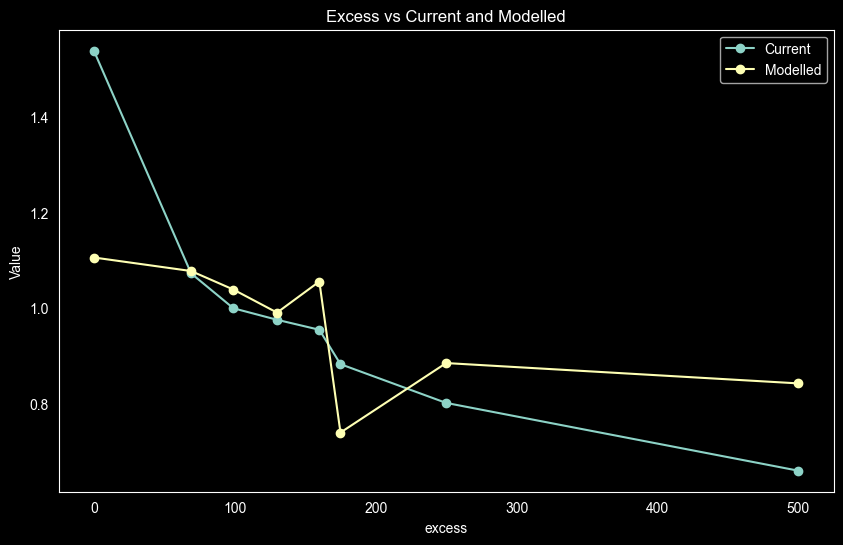

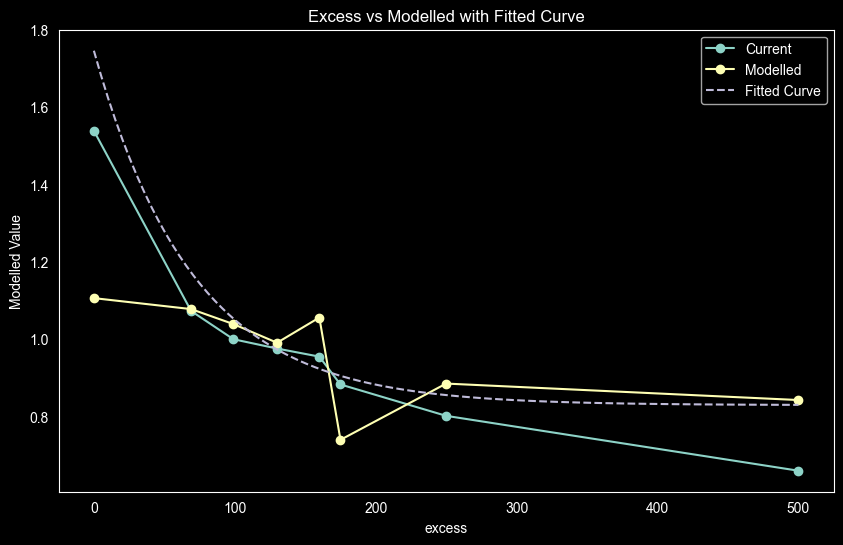

Fitted parameters: a=0.9164, b=0.0142, c=0.8295


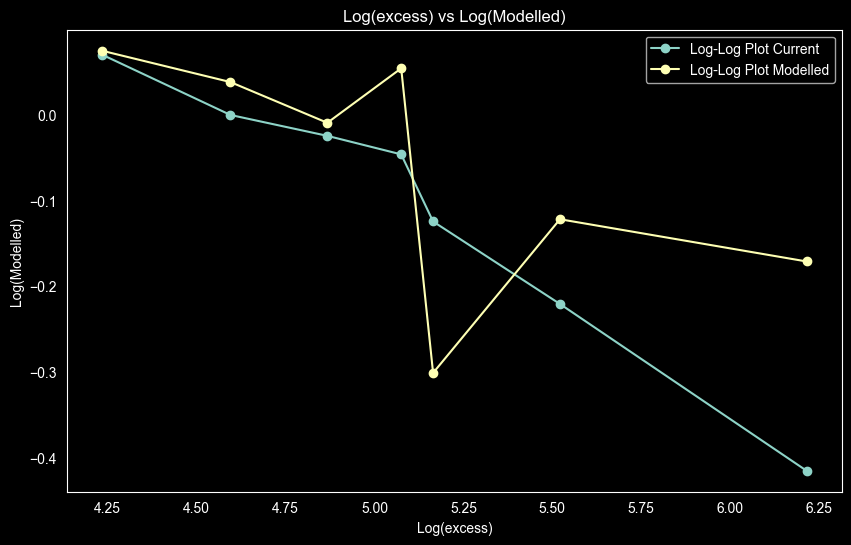

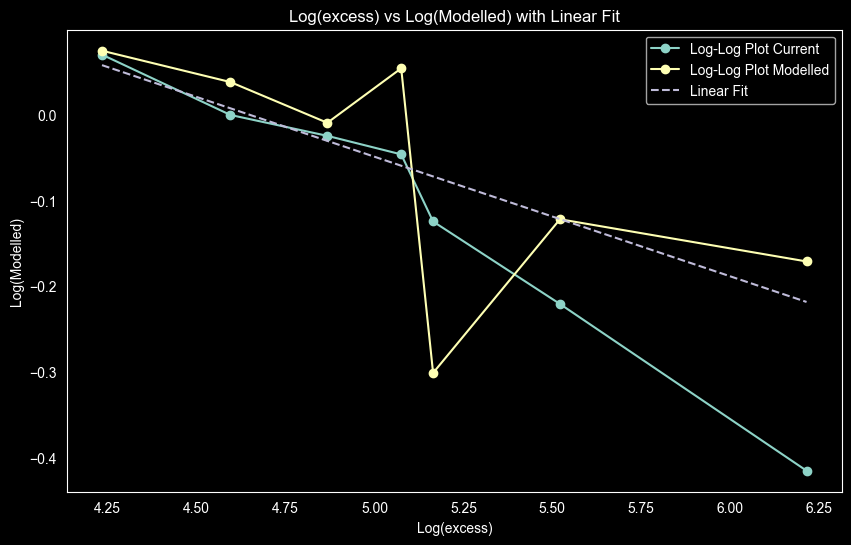

C:\Users\ShivtejJagtap\AppData\Local\Temp\ipykernel_43932\2965476449.py:449: RuntimeWarning: divide by zero encountered in power
  return np.exp(c) * (x)**m


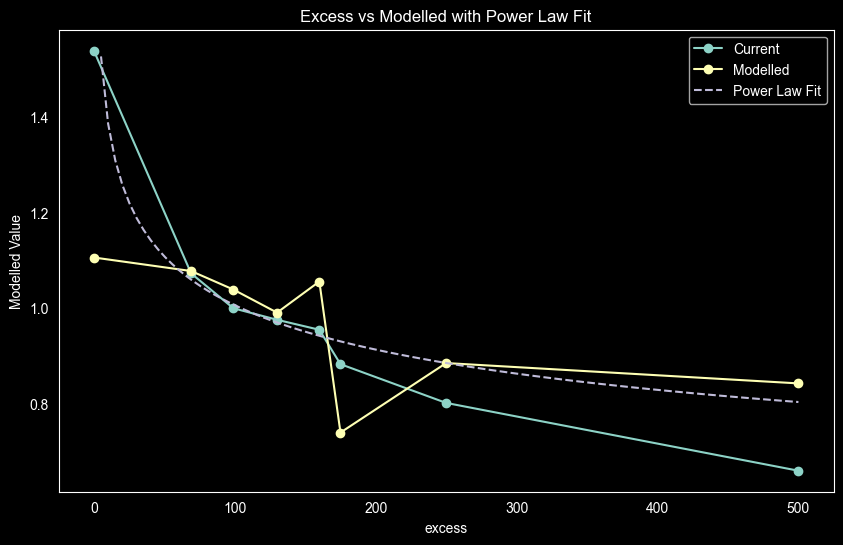

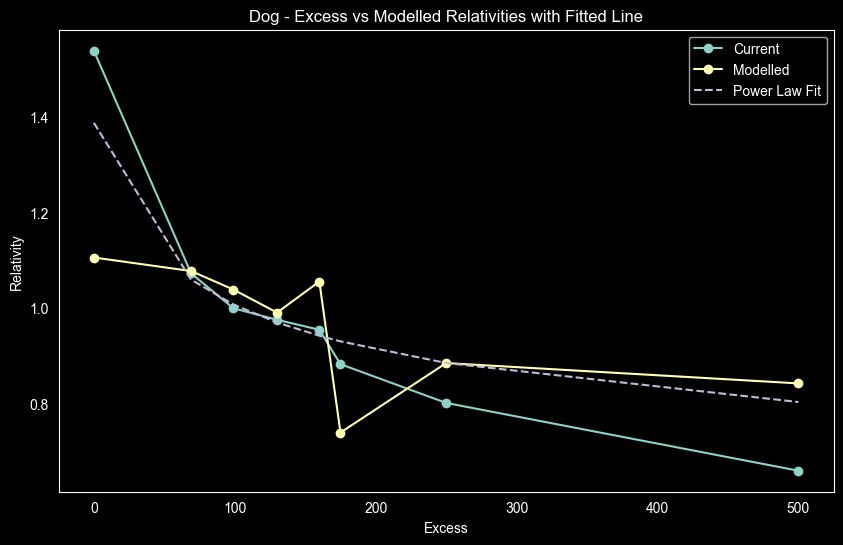

   Power Law Fit  excess
0       1.388104       0
1       1.059908      69
2       1.007794      99
3       0.970172     130
4       0.942442     160
5       0.930720     175
6       0.885494     250
7       0.803792     500


In [1]:
import pylab as pl

from data.burn_cost_glm import BurnCostGLM
import pandas as pd
import numpy as np
from sklearn.isotonic import IsotonicRegression

from matplotlib import pyplot as plt

# -----------------------------
# model and data
# -----------------------------
model = BurnCostGLM()
df_policy_yr = pd.read_parquet('../data/risk_modelling_policy_yr_v2.parquet')

# strip out 1 day exposure
min_exposure = 1 / 365.25
df_policy_yr = df_policy_yr[df_policy_yr['total_exposure'] > min_exposure].copy()

# -----------------------------
# feature engineering
# -----------------------------
first_incep = df_policy_yr.groupby('uuid_pet')['policy_yr'].transform('min')
df_policy_yr['tenure'] = df_policy_yr['policy_yr'] - first_incep

# DOG policies only
df_dog = df_policy_yr.loc[
    (df_policy_yr["pet_type"] == "Dog") &
    (df_policy_yr["total_claim_paid"].notna()) &
    (df_policy_yr["total_claim_paid"] >= 0)
].copy()

# time-based split
df_dog_train = df_dog[
    (df_dog["inception_date_corrected"] >= "2021-01-01") &
    (df_dog["inception_date_corrected"] <= "2024-12-31")
].copy()

df_dog_test = df_dog[
    (df_dog["inception_date_corrected"] >= "2025-01-01") &
    (df_dog["inception_date_corrected"] <= "2025-12-31")
].copy()






##import Dylan's merged dataset for recon
merged_df = pd.read_csv("July_batch_scored_v3.csv")

# DOG policies only
merged_df_dog = merged_df.loc[
    (merged_df["species"] == "Dog")
].copy()

#fix names
##merged_df_dog["BreedBandModel1"] = merged_df_dog["pet_breed_band_v1_int"]
##merged_df_dog["DOG_PC_BAND"] = merged_df_dog["geo_area_band_int"]
##merged_df_dog["pet_age_in_months"] = merged_df_dog["pet_age_months_inception"]
##merged_df_dog["policyholder_age"] = merged_df_dog["owner_age_years_inception"]
##merged_df_dog["pet_value"] = merged_df_dog["pet_value_gbp"]
##merged_df_dog["past_claim_paid_1y"] = 0
##merged_df_dog["past_claim_paid_2y"] = 0
##merged_df_dog["past_claim_paid_3y"] = 0
##merged_df_dog["tenure"] = merged_df_dog["term_number"] - 1
##merged_df_dog["cover_limit"] = merged_df_dog["prod_cover_limit"]
###merged_df_dog["pet_gender"] = merged_df_dog["gender"]

##merged_df_dog["pet_pedigree"] = np.where(merged_df_dog["pedigree_type"]=="PEDIGREE",1,0)

##merged_df_dog["copay"] = merged_df_dog["DEFAULT_COPAY"]
##merged_df_dog["Pre_Ex_Flag"] = merged_df_dog["prod_preex"]
##merged_df_dog["total_exposure"] = 1
##merged_df_dog["excess"] = merged_df_dog["DEFAULT_EXCESS"]



# -----------------------------
# helper functions
# -----------------------------
def ordinal_bucket(x, k: int, min_v: int, max_v: int, invalid: str = "INVALID") -> str:
    if pd.isna(x) or x == -1:
        return invalid
    try:
        x = int(float(x))
    except Exception:
        return invalid
    if min_v <= x <= max_v:
        lo = ((x - min_v) // k) * k + min_v
        hi = lo + (k - 1)
        return f"{lo}_{hi}"
    return invalid

def apply_bin_config(df: pd.DataFrame, config: dict, fillna_label="INVALID", dtype="string"):
    for out_col, spec in config.items():
        src = spec["src"]
        x = pd.to_numeric(df[src], errors="coerce")

        s = pd.cut(
            x,
            bins=spec["bins"],
            labels=spec["labels"],
            right=spec.get("right", False),
            include_lowest=spec.get("include_lowest", True),
        )

        if dtype:
            s = s.astype(dtype)
        if fillna_label is not None:
            s = s.fillna(fillna_label)

        df[out_col] = s

    return df

def make_strictly_increasing(values, min_step=0.05):
    values = np.asarray(values, dtype=float).copy()
    for i in range(1, len(values)):
        min_allowed = values[i - 1] * (1 + min_step)
        if values[i] < min_allowed:
            values[i] = min_allowed
    return values

# -----------------------------
# caps using train only
# -----------------------------
caps = {
    "pet_value": df_dog_train["pet_value"].quantile(0.99),
    "pet_age_in_months": df_dog_train["pet_age_in_months"].quantile(0.99),
    "policyholder_age": df_dog_train["policyholder_age"].quantile(0.99),
}

for df in (df_dog_train,df_dog_test,merged_df_dog):
    df["BreedBandModel1_grp_by3"] = df["BreedBandModel1"].apply(
        ordinal_bucket, k=3, min_v=1, max_v=24, invalid="INVALID"
    )
    df["BreedBandModel1_grp_by4"] = df["BreedBandModel1"].apply(
        ordinal_bucket, k=4, min_v=1, max_v=24, invalid="INVALID"
    )
    df["DOG_PC_BAND_grp_by5"] = df["DOG_PC_BAND"].apply(
        ordinal_bucket, k=5, min_v=1, max_v=58, invalid="INVALID"
    )
    df["pet_age_in_months_capped"] = df["pet_age_in_months"].clip(
    upper=caps["pet_age_in_months"]
    )

    df["pet_age_in_months_grp_by6"] = df["pet_age_in_months_capped"].apply(
        ordinal_bucket, k=6, min_v=1, max_v=int(caps["pet_age_in_months"]), invalid="INVALID"
    )
    df["policyholder_age_grp_by5"] = df["policyholder_age"].apply(
        ordinal_bucket, k=5, min_v=18, max_v=80, invalid="INVALID"
    )

    df["pet_value_q99"] = df["pet_value"].clip(upper=caps["pet_value"])
    df["pet_age_in_months_q99"] = df["pet_age_in_months"].clip(upper=caps["pet_age_in_months"])
    df["policyholder_age_q99"] = df["policyholder_age"].clip(upper=caps["policyholder_age"])

    # claim history
    s1 = df["past_claim_paid_1y"]
    s2 = df["past_claim_paid_2y"]
    s3 = df["past_claim_paid_3y"]
    tenure = df["tenure"]

    c1 = s1.fillna(0) > 0
    c2 = s2.fillna(0) > 0
    c3 = s3.fillna(0) > 0

    has_claim = c1 | c2 | c3
    no_claim = ~has_claim

    df["claim_history_explicit"] = "NB"
    nb = (tenure == 0) | (s1.isna() & s2.isna() & s3.isna())

    df.loc[(~nb) & (tenure == 1) & no_claim, "claim_history_explicit"] = "tenure_1y_no_claim"
    df.loc[(~nb) & (tenure == 1) & has_claim, "claim_history_explicit"] = "tenure_1y_has_claim"
    df.loc[(~nb) & (tenure >= 2) & no_claim, "claim_history_explicit"] = "tenure_2yplus_no_claim"
    df.loc[(~nb) & (tenure >= 2) & has_claim, "claim_history_explicit"] = "tenure_2yplus_has_claim"

# -----------------------------
# bin config
# -----------------------------
bin_config = {
    "tenure_grp": dict(
        src="tenure",
        bins=[0, 1, 2, 3, 4, 5, np.inf],
        labels=["0", "1", "2", "3", "4", "5+"],
        right=False,
    ),
    "ph_age_band": dict(
        src="policyholder_age_q99",
        bins=[0, 25, 35, 40, 45, 55, 65, np.inf],
        labels=["24-", "25-34", "35-39", "40-44", "45-54", "55-64", "65+"],
        right=False,
    ),
    "pet_value_band_1000": dict(
        src="pet_value_q99",
        bins=[0, 1000, 2000, 3000, np.inf],
        labels=["0-999", "1000-1999", "2000-2999", "3000+"],
        right=False,
    ),
    "pet_value_band_500": dict(
        src="pet_value_q99",
        bins=[0, 500, 1000, 1500, 2000, 2500, 3000, np.inf],
        labels=["0-499", "500-999", "1000-1499", "1500-1999", "2000-2499", "2500-2999", "3000+"],
        right=False,
    ),
    "cover_limit_grp": dict(
        src="cover_limit",
        bins=[0, 5001, 10001, np.inf],
        labels=["Essential", "Standard", "Complete"],
        right=False,
    ),
}

for df in (df_dog_train, df_dog_test,merged_df_dog):
    apply_bin_config(df, bin_config)

# -----------------------------
# fit model
# -----------------------------
model.add_categorical_feature("pet_age_in_months_grp_by6", invalid_values=["INVALID"], invalid_label="INVALID")
model.add_categorical_feature("ph_age_band", invalid_values=["INVALID"], invalid_label="INVALID")
model.add_categorical_feature("pet_value_band_1000", invalid_values=["INVALID"], invalid_label="INVALID")
model.add_categorical_feature("claim_history_explicit", invalid_values=["INVALID"], invalid_label="INVALID")
model.add_categorical_feature("BreedBandModel1_grp_by3", invalid_values=["INVALID"], invalid_label="INVALID")
model.add_categorical_feature("DOG_PC_BAND_grp_by5", invalid_values=["INVALID"], invalid_label="INVALID")
model.add_categorical_feature("pet_gender", grouping={"Unknown": "INVALID"}, invalid_values=["INVALID"], invalid_label="INVALID")
model.add_categorical_feature("pet_pedigree", grouping={"Unknown": "INVALID"}, invalid_values=["INVALID"], invalid_label="INVALID")
model.add_categorical_feature("cover_limit", invalid_values=["INVALID"], invalid_label="INVALID")
model.add_categorical_feature("copay", grouping={"Unknown": "INVALID"}, invalid_values=["INVALID"], invalid_label="INVALID")
model.add_categorical_feature("Pre_Ex_Flag", invalid_values=["INVALID"], invalid_label="INVALID")

results = model.fit(
    df_dog_train,
    target="total_claim_paid",
    exposure="total_exposure",
    weight_by_exposure=True,
)

# -----------------------------
# score train/test
# -----------------------------
pred_train = model.predict(df_dog_train, exposure="total_exposure")
pred_test = model.predict(df_dog_test, exposure="total_exposure")

df_dog_train["pred_claim_paid"] = pred_train
df_dog_test["pred_claim_paid"] = pred_test

# -----------------------------
# smooth cover limit relativity
# -----------------------------
rel = pd.DataFrame({
    "cover_limit": [1000, 2000, 3000, 4000, 5000, 7000, 10000, 15000, 20000],
    "relativity": [0.8120294213294983, 0.6741032004356384, 0.6941843032836914, 0.831175684928894,
                   0.8840538859367371, 0.8995975852012634, 0.9146654009819031, 1.0, 0.7577535510063171]
})

exp = pd.DataFrame({
    "cover_limit": [1000, 10000, 15000, 2000, 20000, 3000, 4000, 5000, 7000],
    "total_exposure": [329.596167, 2163.780972, 79554.918549, 2195.715264,
                       744.4846, 23710.683094, 2337.779603, 1884.391513, 48633.237509]
})

table = (
    rel.merge(exp, on="cover_limit", how="left")
       .sort_values("cover_limit")
       .reset_index(drop=True)
)

iso = IsotonicRegression(increasing=True, out_of_bounds="clip")
table["rel_iso"] = iso.fit_transform(
    table["cover_limit"],
    table["relativity"],
    sample_weight=table["total_exposure"]
)

table["rel_strict"] = make_strictly_increasing(table["rel_iso"], min_step=0.05)

base = table.loc[table["cover_limit"] == 15000, "rel_strict"].iloc[0]
table["rel_strict_rebased"] = table["rel_strict"] / base

print(table[["cover_limit", "relativity", "total_exposure", "rel_iso", "rel_strict_rebased"]])


# plot table showing difference between old and new relativities
plt.figure(figsize=(10, 6))
plt.plot(table['cover_limit'], table['relativity'], label='Initial', marker='o')
plt.plot(table['cover_limit'], table['rel_strict_rebased'], label='Smoothed Monotonic', marker='o')
plt.xlabel('Cover_limit')
plt.ylabel('Relativity')
plt.title('Dog - Initial vs Smoothed Monotonic Cover Limit Relativity')
plt.legend()
plt.grid()
plt.show()






# -----------------------------
# replace raw cover effect with smoothed cover effect
# -----------------------------
df_dog_train["cover_limit"] = df_dog_train["cover_limit"].astype(float)
df_dog_test["cover_limit"] = df_dog_test["cover_limit"].astype(float)

raw_rel_map = table.set_index("cover_limit")["relativity"].to_dict()
smooth_rel_map = table.set_index("cover_limit")["rel_strict_rebased"].to_dict()

df_dog_train["cover_rel_raw"] = df_dog_train["cover_limit"].map(raw_rel_map)
df_dog_train["cover_rel_smooth"] = df_dog_train["cover_limit"].map(smooth_rel_map)

df_dog_test["cover_rel_raw"] = df_dog_test["cover_limit"].map(raw_rel_map)
df_dog_test["cover_rel_smooth"] = df_dog_test["cover_limit"].map(smooth_rel_map)

df_dog_train["pred_claim_paid_cover_smoothed"] = (
    df_dog_train["pred_claim_paid"]
    * df_dog_train["cover_rel_smooth"]
    / df_dog_train["cover_rel_raw"]
)

df_dog_test["pred_claim_paid_cover_smoothed"] = (
    df_dog_test["pred_claim_paid"]
    * df_dog_test["cover_rel_smooth"]
    / df_dog_test["cover_rel_raw"]
)

# -----------------------------
# build calibration on test, apply to test
# -----------------------------

###  use the raw factor (i.e. the residual on the test set) then use below to smooth


df_dog_test["excess"] = pd.to_numeric(df_dog_test["excess"], errors="coerce")
df_dog_train["excess"] = pd.to_numeric(df_dog_train["excess"], errors="coerce")

df_dog_test = df_dog_test[df_dog_test["excess"] != 106.0].copy()

calib_table = (
    df_dog_test
    .groupby("excess", dropna=False)
    .agg(
        actual=("total_claim_paid", "sum"),
        predicted=("pred_claim_paid_cover_smoothed", "sum"),
        Weight=("total_exposure", "sum"),
    )
    .reset_index()
)

calib_table["Modelled"] = calib_table["actual"] / calib_table["predicted"]



########### smoothing step for after calibration

import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# create excess table
excess_df = pd.DataFrame({
    'excess': [0, 69, 99, 130, 160, 175, 250, 500],
    'Current': [1.539, 1.073, 1, 0.9759, 0.955, 0.883, 0.8019, 0.66]
})

#join calibration
excess_df = excess_df.merge(
    calib_table[["Weight", "Modelled","excess"]],
    on="excess",
    how="left"
)

# plot excess vs current and modelled
plt.figure(figsize=(10, 6))
plt.plot(excess_df['excess'], excess_df['Current'], label='Current', marker='o')
plt.plot(excess_df['excess'], excess_df['Modelled'], label='Modelled', marker='o')
plt.xlabel('excess')
plt.ylabel('Value')
plt.title('Excess vs Current and Modelled')
plt.legend()
plt.grid()
plt.show()

# fit a curve to smooth the modelled values
def model_func(x, a, b, c):
    return a * np.exp(-b * x) + c

# fit just to excess between 99 and 250
mask = (excess_df['excess'] >= 99) & (excess_df['excess'] <= 250)
popt, pcov = curve_fit(model_func, excess_df['excess'][mask], excess_df['Modelled'][mask], p0=(0.5582, 0.0103, 0.8001),)
# plot the fitted curve
x_fit = np.linspace(0, 500, 100)
y_fit = model_func(x_fit, *popt)
plt.figure(figsize=(10, 6))

plt.plot(excess_df['excess'], excess_df['Current'], label='Current', marker='o')
plt.plot(excess_df['excess'], excess_df['Modelled'], label='Modelled', marker='o')
plt.plot(x_fit, y_fit, label='Fitted Curve', linestyle='--')
plt.xlabel('excess')
plt.ylabel('Modelled Value')
plt.title('Excess vs Modelled with Fitted Curve')
plt.legend()
plt.grid()
plt.show()
# print the fitted parameters
print(f'Fitted parameters: a={popt[0]:.4f}, b={popt[1]:.4f}, c={popt[2]:.4f}')

# plot log of excess vs log of modelled to see if it is linear
#exclude 0 excess values to avoid log(0)
excess_df_nonzero = excess_df[excess_df['excess'] > 0]
plt.figure(figsize=(10, 6))
# also plot curtrent
plt.plot(np.log(excess_df_nonzero['excess']), np.log(excess_df_nonzero['Current']), label='Log-Log Plot Current', marker='o')
plt.plot(np.log(excess_df_nonzero['excess']), np.log(excess_df_nonzero['Modelled']), label='Log-Log Plot Modelled', marker='o')
plt.xlabel('Log(excess)')
plt.ylabel('Log(Modelled)')
plt.title('Log(excess) vs Log(Modelled)')
plt.legend()
plt.grid()
plt.show()

# fit a linear model to the log-log data
def linear_model(x, m, c):
    return m * (x) + c # add a small constant to x to avoid log(0) issues

popt_linear, pcov_linear = curve_fit(
    linear_model, np.log(excess_df_nonzero['excess']),
    np.log(excess_df_nonzero['Modelled']),
    #sigma=1/excess_df_nonzero['Weight']
    )
# plot the linear fit on the log-log plot
x_fit_linear = np.linspace(np.log(excess_df_nonzero['excess'].min()), np.log(excess_df_nonzero['excess'].max()), 100)
y_fit_linear = linear_model(x_fit_linear, *popt_linear)
plt.figure(figsize=(10, 6))
plt.plot(np.log(excess_df_nonzero['excess']), np.log(excess_df_nonzero['Current']), label='Log-Log Plot Current', marker='o')
plt.plot(np.log(excess_df_nonzero['excess']), np.log(excess_df_nonzero['Modelled']), label='Log-Log Plot Modelled', marker='o')
plt.plot(x_fit_linear, y_fit_linear, label='Linear Fit', linestyle='--')
plt.xlabel('Log(excess)')
plt.ylabel('Log(Modelled)')
plt.title('Log(excess) vs Log(Modelled) with Linear Fit')
plt.legend()
plt.grid()
plt.show()

# plot the transformed data on the original scale using the linear fit parameters
# if the model is linear in log-log space, then we can express it as Modelled = exp(c) * Excess^m
def power_law_model(x, m, c):
    return np.exp(c) * (x)**m
x_fit = np.linspace(0, 500, 100)
y_fit_power_law = power_law_model(x_fit, *popt_linear)
plt.figure(figsize=(10, 6))
plt.plot(excess_df['excess'], excess_df['Current'], label='Current', marker='o')
plt.plot(excess_df['excess'], excess_df['Modelled'], label='Modelled', marker='o')
plt.plot(x_fit, y_fit_power_law, label='Power Law Fit', linestyle='--')
plt.xlabel('excess')
plt.ylabel('Modelled Value')
plt.title('Excess vs Modelled with Power Law Fit')
plt.legend()
plt.grid()
plt.show()

# get predictions from the original model function
excess_df['Model Function Fit'] = model_func(excess_df['excess'], *popt)
# get predictions from the power law model
excess_df['Power Law Fit'] = power_law_model(np.where(excess_df['excess']<10, 10, excess_df['excess']), *popt_linear)
# plot the power law fit against the original data


# plot all 4 on the same plot
plt.figure(figsize=(10, 6))
plt.plot(excess_df['excess'], excess_df['Current'], label='Current', marker='o')
plt.plot(excess_df['excess'], excess_df['Modelled'], label='Modelled', marker='o')
### plt.plot(excess_df['excess'], excess_df['Model Function Fit'], label='Model Function Fit', linestyle='--')
plt.plot(excess_df['excess'], excess_df['Power Law Fit'], label='Power Law Fit', linestyle='--')
plt.xlabel('Excess')
plt.ylabel('Relativity')
plt.title('Dog - Excess vs Modelled Relativities with Fitted Line')
plt.legend()
plt.grid()
plt.show()



### Join on the power law fit onto the test and train datasets
df_dog_train = df_dog_train.merge(
    excess_df[["Power Law Fit","excess"]],
    on="excess",
    how="left"
    )

df_dog_test = df_dog_test.merge(
    excess_df[["Power Law Fit","excess"]],
    on="excess",
    how="left"
    )


## Multiply predictions by power law fit
df_dog_train["pred_claim_paid_final"] = df_dog_train["pred_claim_paid_cover_smoothed"] * df_dog_train["Power Law Fit"]

df_dog_test["pred_claim_paid_final"] = df_dog_test["pred_claim_paid_cover_smoothed"] * df_dog_test["Power Law Fit"]


## print Power Law Fit relativities
print(excess_df[["Power Law Fit","excess"]])



In [33]:
print(results.summary())
# # -----------------------
# # use outputs
# # -----------------------
relativities = model.factor_relativity()
defaults = model.numeric_defaults()
#
pred_train = model.predict(df_dog_train, exposure="total_exposure")
pred_test = model.predict(df_dog_test, exposure="total_exposure")
#
print(defaults)
print(relativities)
#
for factor, df in relativities.items():
    df.to_csv(f"relativity_{factor}.csv", index=False)

                 Generalized Linear Model Regression Results                  
Dep. Variable:       total_claim_paid   No. Observations:              1621320
Model:                            GLM   Df Residuals:                  1621296
Model Family:                 Tweedie   Df Model:                           23
Link Function:                    Log   Scale:                          331.71
Method:                          IRLS   Log-Likelihood:            -3.9472e+06
Date:                Tue, 28 Apr 2026   Deviance:                   1.1845e+08
Time:                        14:21:13   Pearson chi2:                 5.38e+08
No. Iterations:                    14   Pseudo R-squ. (CS):            0.02288
Covariance Type:            nonrobust                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [7]:
import re
from matplotlib import pyplot as plt

def _sort_index_smart(g):
    idx_str = g.index.astype(str)

    #pure numeric
    idx_num = pd.to_numeric(idx_str, errors="coerce")
    if not idx_num.isna().all():
        return g.assign(_idx=idx_num).sort_values("_idx").drop(columns="_idx")

#########################  need to change either this bit or change number of bands???

    #extracting leading number from band
    def extract_lower_bound(x):
        match = re.match(r"(-?\d+\.?\d*)", x)
        if match:
            return float(match.group(1))
        return np.nan

    lower_bounds = idx_str.map(extract_lower_bound)

    if not lower_bounds.isna().all():
        return g.assign(_idx=lower_bounds).sort_values("_idx").drop(columns="_idx")

    #fallback to alphabetical
    return g.sort_index()


def _aggregate_actual_pred(df, group_col, *, actual_col, pred_col, exposure_col):
    g = df.groupby(group_col, observed=True).agg(
        actual_sum=(actual_col, "sum"),
        pred_sum=(pred_col, "sum"),
        exposure_sum=(exposure_col, "sum"),
    )
    g = _sort_index_smart(g)

    # avoid division issues
    exp = g["exposure_sum"].replace(0, np.nan)
    g["actual_avg"] = g["actual_sum"] / exp
    g["pred_avg"] = g["pred_sum"] / exp

    return g


def _plot_exposure_two_lines(g, x_labels, title, rotate=90):
    fig, ax = plt.subplots(1, 1, figsize=(12, 5))

    # --- Plot 1: Average claim paid (Actual vs Pred) ---
    ax.bar(x_labels, g["exposure_sum"], alpha=0.35)
    ax.set_ylabel('Exposure')

    ax_t = ax.twinx()
    ax_t.plot(x_labels, g["actual_avg"], marker="o", label="Actual avg claim")
    ax_t.plot(x_labels, g["pred_avg"], marker="o", label="Pred avg claim")
    ax_t.set_ylabel("Avg claim paid")
    ax.set_title(f"{title} - Avg claim (Actual vs Pred)")
    ax_t.legend(loc="best")

    if rotate:
        ha = "right" if rotate else "center"
        plt.setp(ax.get_xticklabels(), rotation=rotate, ha=ha, rotation_mode="anchor")

    plt.tight_layout()
    plt.show()


def plot_cat_exposure_actual_pred_coef(df, col, *, actual_col, pred_col, exposure_col="total_exposure"):
    g = _aggregate_actual_pred(df, col, actual_col=actual_col, pred_col=pred_col, exposure_col=exposure_col)
    x = g.index.astype(str)
    _plot_exposure_two_lines(g, x, title=col, rotate=45)

###### change bins label here?
def plot_num_exposure_actual_pred_coef(df, col, *, actual_col, pred_col, exposure_col="total_exposure", bins=20):

    df1 = pd.DataFrame({
    "bin_name": [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],
    })

    binned = pd.cut(df[col], bins=bins, labels=df1["bin_name"]) ### change needs to be here or functions this calls?
    g = _aggregate_actual_pred(df, binned, actual_col=actual_col, pred_col=pred_col, exposure_col=exposure_col)
    x = g.index.astype(str)
    _plot_exposure_two_lines(g, x, title=col, rotate=90)

In [8]:

numeric_cols = [
    'pet_age_in_months_q99',
    'pet_value_q99',
    'policyholder_age_q99',
]

categorical_cols =[
    'pet_age_in_months',
    'policyholder_age',
    'BreedBandModel1',
     "pet_age_in_months_grp_by6",
    'ph_age_band',
    'pet_value_band_1000',
    'policy_yr',
    'pet_gender',
    'pet_pedigree',
    'pet_is_neutered_spayed',
    'excess',
    'copay',
    'cover_limit',
    'nb_flag',
    'BreedBandModel1_grp_by3',
    'DOG_PC_BAND_grp_by5',
    'tenure_grp',
    'claim_history_explicit',
    'Pre_Ex_Flag'
]

for col in numeric_cols:
    plot_num_exposure_actual_pred_coef(df_dog_train, col, actual_col='total_claim_paid', pred_col='pred_claim_paid_final', exposure_col="total_exposure", bins=22)
for col in categorical_cols:
    plot_cat_exposure_actual_pred_coef(df_dog_train, col, actual_col='total_claim_paid', pred_col='pred_claim_paid_final', exposure_col="total_exposure")

ValueError: Bin labels must be one fewer than the number of bin edges

In [ ]:

for col in numeric_cols:
    plot_num_exposure_actual_pred_coef(df_dog_test, col, actual_col='total_claim_paid', pred_col='pred_claim_paid_final', exposure_col="total_exposure", bins=30)
for col in categorical_cols:
    plot_cat_exposure_actual_pred_coef(df_dog_test, col, actual_col='total_claim_paid', pred_col='pred_claim_paid_final', exposure_col="total_exposure")



In [ ]:
def weighted_gini(actual, pred, weight):
    df = pd.DataFrame({
        "actual": actual,
        "pred": pred,
        "weight": weight
    }).sort_values("pred", ascending=False)

    df["cum_weight"] = df["weight"].cumsum()
    df["cum_actual"] = (df["actual"] * df["weight"]).cumsum()

    total_weight = df["weight"].sum()
    total_actual = (df["actual"] * df["weight"]).sum()

    df["lorentz"] = df["cum_actual"] / total_actual
    df["random"] = df["cum_weight"] / total_weight

    gini = ((df["lorentz"] - df["random"]) * df["weight"]).sum() / total_weight
    return gini


def normalized_weighted_gini(actual, pred, weight):
    gini_model = weighted_gini(actual, pred, weight)
    gini_perfect = weighted_gini(actual, actual, weight)
    return gini_model / gini_perfect

# TRAIN
gini_train = normalized_weighted_gini(
    df_dog_train["total_claim_paid"],
    df_dog_train["pred_claim_paid_final"],
    df_dog_train["total_exposure"]
)

# TEST
gini_test = normalized_weighted_gini(
    df_dog_test["total_claim_paid"],
    df_dog_test["pred_claim_paid_final"],
    df_dog_test["total_exposure"]
)

print(f"Train weighted Gini: {gini_train:.4f}")
print(f"Test  weighted Gini: {gini_test:.4f}")

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -----------------------------
# weighted summary helpers
# -----------------------------
def weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    return np.sum(w * x) / np.sum(w)

def weighted_std(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mu = weighted_mean(x, w)
    var = np.sum(w * (x - mu) ** 2) / np.sum(w)
    return np.sqrt(var)

def weighted_quantile(x, w, q):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)

    mask = ~(np.isnan(x) | np.isnan(w))
    x = x[mask]
    w = w[mask]

    order = np.argsort(x)
    x = x[order]
    w = w[order]

    cum_w = np.cumsum(w)
    cutoff = q * np.sum(w)
    return x[np.searchsorted(cum_w, cutoff, side="left")]


# -----------------------------
# weights
# -----------------------------
w_train = df_dog_train["total_exposure"]
w_test = df_dog_test["total_exposure"]

# -----------------------------
# weighted RMSE / MAE
# -----------------------------
rmse_train_w = np.sqrt(mean_squared_error(
    df_dog_train["total_claim_paid"],
    df_dog_train["pred_claim_paid_cover_smoothed"],
    sample_weight=w_train
))

rmse_test_w = np.sqrt(mean_squared_error(
    df_dog_test["total_claim_paid"],
    df_dog_test["pred_claim_paid_final"],
    sample_weight=w_test
))

mae_train_w = mean_absolute_error(
    df_dog_train["total_claim_paid"],
    df_dog_train["pred_claim_paid_cover_smoothed"],
    sample_weight=w_train
)

mae_test_w = mean_absolute_error(
    df_dog_test["total_claim_paid"],
    df_dog_test["pred_claim_paid_final"],
    sample_weight=w_test
)

print(f"Weighted Train RMSE: {rmse_train_w:.4f}")
print(f"Weighted Test  RMSE: {rmse_test_w:.4f}")
print(f"Weighted Train MAE : {mae_train_w:.4f}")
print(f"Weighted Test  MAE : {mae_test_w:.4f}")


# -----------------------------
# weighted actual distribution summary
# -----------------------------
train_actual = df_dog_train["total_claim_paid"]
test_actual = df_dog_test["total_claim_paid"]

print(f"Weighted Train mean: {weighted_mean(train_actual, w_train):.4f}")
print(f"Weighted Test  mean: {weighted_mean(test_actual, w_test):.4f}")

print(f"Weighted Train std : {weighted_std(train_actual, w_train):.4f}")
print(f"Weighted Test  std : {weighted_std(test_actual, w_test):.4f}")

print(f"Weighted Train p99 : {weighted_quantile(train_actual, w_train, 0.99):.4f}")
print(f"Weighted Test  p99 : {weighted_quantile(test_actual, w_test, 0.99):.4f}")

In [ ]:
# TRAIN
lr_train = (
    df_dog_train["total_claim_paid"].sum()
    / df_dog_train["pred_claim_paid_final"].sum()
)

# TEST
lr_test = (
    df_dog_test["total_claim_paid"].sum()
    / df_dog_test["pred_claim_paid_final"].sum()
)

print(f"Train LR: {lr_train:.4f}")
print(f"Test  LR: {lr_test:.4f}")

In [ ]:
import numpy as np

df_dog_test["rand_row_num"] =  np.random.uniform(low=0.0, high=1.0, size=293692)


plot_num_exposure_actual_pred_coef(df_dog_test, "rand_row_num", actual_col='total_claim_paid', pred_col='pred_claim_paid_final', exposure_col="total_exposure", bins=5)

In [ ]:

#### "Single Lift Chart"

import numpy as np

### rank rows by predicted values
df_dog_test['Rank'] = df_dog_test['pred_claim_paid_final'].rank(method='first', ascending=True)
df_dog_test.sort_values(['Rank'], ascending=[True],inplace=True)

### sort into bins of roughly equal exposure via cumulative sum

df_dog_test['Dog Single Lift'] = df_dog_test['total_exposure'].cumsum()


### plot graph for those categories
plot_num_exposure_actual_pred_coef(df_dog_test, 'Dog Single Lift', actual_col='total_claim_paid', pred_col='pred_claim_paid_final', exposure_col="total_exposure", bins=20)


In [ ]:
#### test dataset AVE

import numpy as np

def plot_date_exposure_actual_pred_coef(df, col, *, actual_col, pred_col, exposure_col="total_exposure", bins=12):

    df1 = pd.DataFrame({
        "month": ["January","February","March","April","May","June","July","August","September","October","November","December"],
        })

    binned = pd.cut(df[col], bins=bins, labels=df1["month"])
    g = _aggregate_actual_pred(df, binned, actual_col=actual_col, pred_col=pred_col, exposure_col=exposure_col)
    x = g.index.astype(str)
    _plot_exposure_two_lines(g, x, title=col, rotate=90)

plot_date_exposure_actual_pred_coef(df_dog_test, "inception_date_corrected", actual_col='total_claim_paid', pred_col='pred_claim_paid_final', exposure_col="total_exposure", bins=12)


In [ ]:
### want:
### x-axis labels (NB,Dog, Agg),(NB,Dog, Direct), (NB,Cat, Agg), (NB, Cat, Direct), (RB, Dog) and (RB,Cat).
### basically just need to create and bring through a new field: agg/direct AND NB/RN . Still do separately cat/dog. Just use the categorical feature.

plot_cat_exposure_actual_pred_coef(df_dog_test, 'Agg_Direct_NB_RN'
, actual_col='total_claim_paid', pred_col='pred_claim_paid_final', exposure_col="total_exposure")



In [ ]:
### create quarterly exposure

import numpy as np

def plot_quarter_exposure_actual_pred_coef(df, col, *, actual_col, pred_col, exposure_col="total_exposure", bins=16):

    df1 = pd.DataFrame({
        "quarter": ["2021_Q1","2021_Q2","2021_Q3","2021_Q4","2022_Q1","2022_Q2","2022_Q3","2022_Q4","2023_Q1","2023_Q2","2023_Q3","2023_Q4","2024_Q1","2024_Q2","2024_Q3","2024_Q4"],
        })

    binned = pd.cut(df[col], bins=bins, labels=df1["quarter"])
    g = _aggregate_actual_pred(df, binned, actual_col=actual_col, pred_col=pred_col, exposure_col=exposure_col)
    x = g.index.astype(str)
    _plot_exposure_two_lines(g, x, title=col, rotate=90)

plot_quarter_exposure_actual_pred_coef(df_dog_train, "inception_date_corrected", actual_col='total_claim_paid', pred_col='pred_claim_paid_final', exposure_col="total_exposure", bins=16)



import numpy as np

def plot_quarter_exposure_actual_pred_coef_v2(df, col, *, actual_col, pred_col, exposure_col="total_exposure", bins=4):

    df1 = pd.DataFrame({
        "quarter": ["2025_Q1","2025_Q2","2025_Q3","2025_Q4"],
        })

    binned = pd.cut(df[col], bins=bins, labels=df1["quarter"])
    g = _aggregate_actual_pred(df, binned, actual_col=actual_col, pred_col=pred_col, exposure_col=exposure_col)
    x = g.index.astype(str)
    _plot_exposure_two_lines(g, x, title=col, rotate=90)

plot_quarter_exposure_actual_pred_coef_v2(df_dog_test, "inception_date_corrected", actual_col='total_claim_paid', pred_col='pred_claim_paid_final', exposure_col="total_exposure", bins=4)







from sklearn.linear_model import LinearRegression
from datetime import datetime

# fit a linear model to each line to find intersection
# we are assuming that the predicted model is as-at one point in time
df_dog_train['line_predicted'] = df_dog_train["pred_claim_paid_final"].mean()


### idea: turn inception date into no. of days?
df_dog_train["days_in"] = df_dog_train["inception_date_corrected"] - datetime(2021,1,1)
df_dog_train["days_in"] = df_dog_train["days_in"].to_numpy().astype(float)

X = df_dog_train[["days_in"]]
Y = df_dog_train["total_claim_paid"]
model = LinearRegression()
model.fit(X,Y)

df_dog_train['line_actual'] = model.predict(df_dog_train[["days_in"]])

# plot lines on same graph
plt.figure(figsize=(10, 6))
plt.plot(df_dog_train['inception_date_corrected'], df_dog_train['line_actual'], label='Actual', marker='o')
plt.plot(df_dog_train['inception_date_corrected'], df_dog_train['line_predicted'], label='Predicted', marker='o')
plt.xlabel('Inception Date')
plt.ylabel('Avg Claim Cost')
plt.title('Dog Actual vs Predicted Over Time')
plt.legend()
plt.grid()
plt.show()




### Indicates model is giving predictions as-at Q2 2023




In [ ]:
### print quarterly AvEs


#train
print("train")

df_dog_train["quarter"] = (df_dog_train["inception_date_corrected"].dt.year) * 100 + (df_dog_train["inception_date_corrected"].dt.quarter)

df2 = df_dog_train[['quarter', 'pred_claim_paid_final','total_claim_paid']].copy()

print(df2.groupby("quarter").agg('mean'))


#test
print("test")


df_dog_test["quarter"] = (df_dog_test["inception_date_corrected"].dt.year) * 100 + (df_dog_test["inception_date_corrected"].dt.quarter)

df3 = df_dog_test[['quarter', 'pred_claim_paid_final','total_claim_paid']].copy()

print(df3.groupby("quarter").agg('mean'))


In [ ]:
# print rn/nb & agg/direct predicted and actual sums for rebasing

#train
print("train")

df2 = df_dog_train[['Agg_Direct_NB_RN', 'pred_claim_paid_cover_smoothed','total_claim_paid']].copy()

print(df2.groupby("Agg_Direct_NB_RN").agg('sum'))


#test
print("test")

df_dog_test["quarter"] = (df_dog_test["inception_date_corrected"].dt.year) * 100 + (df_dog_test["inception_date_corrected"].dt.quarter)


df4 = df_dog_test[['Agg_Direct_NB_RN', 'pred_claim_paid_final','total_claim_paid','quarter']].copy()

print(df4.groupby(["Agg_Direct_NB_RN","quarter"]).agg('sum'))


In [11]:
### take first few rows of dataset

df_dog_test_row1 = df_dog_test.head(5)

pd.set_option("display.max_columns", None) # Show all columns

print(df_dog_test_row1)

                               uuid_pet inception_date_corrected  policy_yr  \
0  000024eb-3d5b-4501-94d6-fc65aa1bbe31               2025-09-15       2025   
1  00004fad-e8a0-425e-ac52-f4691d1d44a5               2025-08-15       2025   
2  0000d417-092a-4ab4-8f0e-63ac2188bbad               2025-12-02       2025   
3  0000f91c-0f2e-4f29-b4a4-8145c8948752               2025-06-25       2025   
4  000169b6-3488-4aae-856f-fe98b3e95baf               2025-04-24       2025   

   total_exposure pet_type            pet_breed  pet_age_in_months pet_gender  \
0        0.583162      Dog             LABRADOR               74.0       Male   
1        0.668036      Dog   MIXED_BREED_MEDIUM               52.0     Female   
2         0.36961      Dog     SPROCKER_SPANIEL               63.0     Female   
3        0.807666      Dog       AMERICAN_AKITA               29.0     Female   
4        0.999316      Dog  MINIATURE_SCHNAUZER               39.0       Male   

  pet_pedigree pet_is_neutered_spayed 

In [20]:
##score dog rows on Dylan's dataset for reconciliation




### import, filter and group dylan's dataset earlier


# score
pred_merged = model.predict(merged_df_dog, exposure="total_exposure")

merged_df_dog["pred_claim_paid"] = pred_merged


# -----------------------------
# replace raw cover effect with smoothed cover effect
# -----------------------------
merged_df_dog["cover_limit"] = merged_df_dog["cover_limit"].astype(float)

raw_rel_map = table.set_index("cover_limit")["relativity"].to_dict()
smooth_rel_map = table.set_index("cover_limit")["rel_strict_rebased"].to_dict()


merged_df_dog["cover_rel_raw"] = merged_df_dog["cover_limit"].map(raw_rel_map)
merged_df_dog["cover_rel_smooth"] = merged_df_dog["cover_limit"].map(smooth_rel_map)


merged_df_dog["pred_claim_paid_cover_smoothed"] = (
    merged_df_dog["pred_claim_paid"]
    * merged_df_dog["cover_rel_smooth"]
    / merged_df_dog["cover_rel_raw"]
)

### excess layer
### Join on the power law fit onto the test and train datasets
merged_df_dog = merged_df_dog.merge(
    excess_df[["Power Law Fit","excess"]],
    on="excess",
    how="left"
    )

## Multiply predictions by power law fit
merged_df_dog["pred_claim_paid_final"] = merged_df_dog["pred_claim_paid_cover_smoothed"] * merged_df_dog["Power Law Fit"]


merged_df_dog.to_csv('merged_dog_data_scored_June_1905.csv', index=False)


In [21]:
merged_df_dog.to_csv('merged_dog_data_scored_June_1905.csv', index=False)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
merged_df = pd.read_csv("July_batch_scored_v3.csv")
risk_features = [
    'BreedBandModel1',
    'CAT_PC_BAND',
    'pet_age_in_months',
    'policyholder_age',
    'pet_value',

    'tenure',
    'cover_limit',
    'pet_gender',

    'pet_pedigree',

    'copay',
    'Pre_Ex_Flag',
    'total_exposure',
    'excess',
]

for col in risk_features:

    counts = df[col].fillna('Missing').value_counts(dropna=False)

    plt.figure(figsize=(10, 5))

    sns.barplot(
        x=counts.index.astype(str),
        y=counts.values
    )
    plt.title(f'Distribution of {col} (cat)')
    plt.xlabel('Rating factor levels')
    plt.ylabel('count of policy')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


    missing_pct = df[col].isna().mean()*100

    print(f"\n{'='*60}")
    print(f"Feature: {col}")
    print(f"Missing: {missing_pct:.2f}%")


    top_level_pct = counts.iloc[0] / counts.sum() * 100

    print(f" level concentration: {top_level_pct:.2f}%")

    if top_level_pct > 80:
        print(" Highly concentrated")

    if missing_pct > 50:
        print("High missing rate")

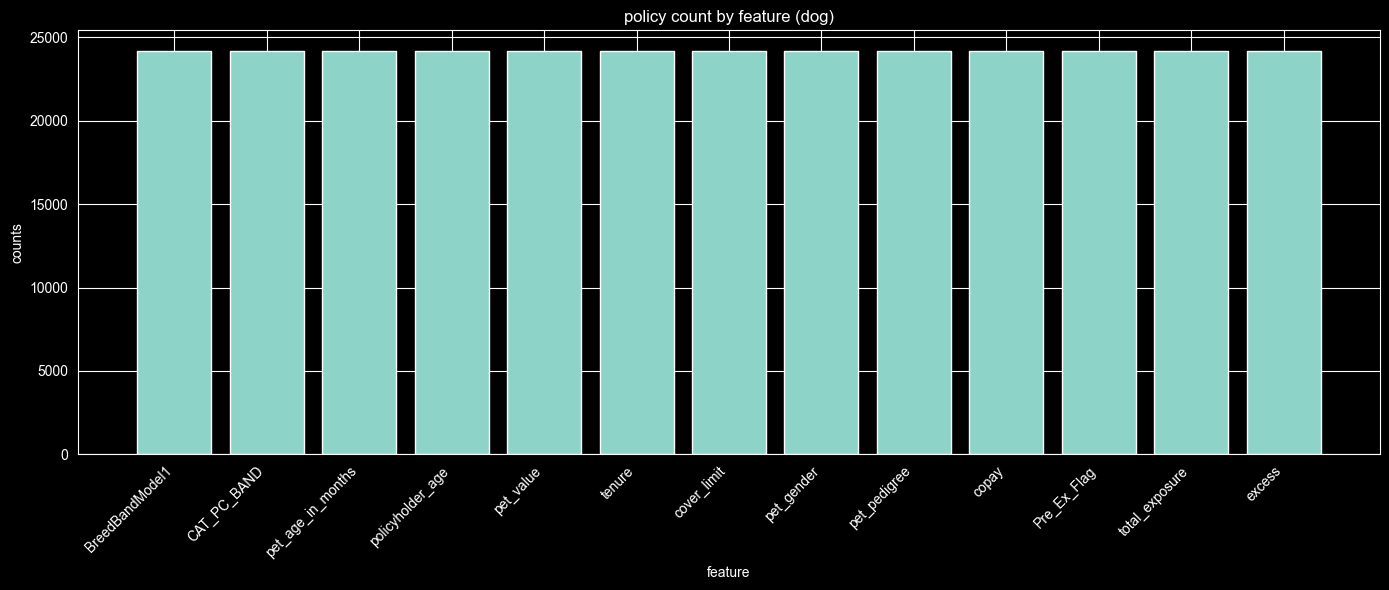

In [33]:
policy_counts = []
for col in risk_features:
    policy_counts.append(df[col].count())

summary_df = pd.DataFrame({
    'feature': risk_features,
    'policy_count': policy_counts,
})

plt.figure(figsize=(14, 6))

plt.bar(
    summary_df['feature'],
    summary_df['policy_count'],
)

plt.title('policy count by feature (dog)')
plt.xlabel('feature')
plt.ylabel('counts')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [53]:
import os
folder_name = "risk_factor_graphs_1"
os.makedirs(folder_name, exist_ok=True)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile

merged_df = pd.read_csv("July_batch_scored_v3.csv")
risk_features = [
    'BreedBandModel1',
    'CAT_PC_BAND',
    'pet_age_in_months',
    'policyholder_age',
    'pet_value',

    'tenure',
    'cover_limit',
    'pet_gender',

    'pet_pedigree',

    'copay',
    'Pre_Ex_Flag',
    'total_exposure',
    'excess',
]

for col in risk_features:

    counts = df[col].fillna('Missing').value_counts(dropna=False)

    plt.figure(figsize=(10, 5))

    sns.barplot(
        x=counts.index.astype(str),
        y=counts.values
    )
    plt.title(f'Distribution of {col} (cat)')
    plt.xlabel('Rating factor levels')
    plt.ylabel('count of policy')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    missing_pct = df[col].isna().mean() * 100

    print(f"\n{'=' * 60}")
    print(f"Feature: {col}")
    print(f"Missing: {missing_pct:.2f}%")

    top_level_pct = counts.iloc[0] / counts.sum() * 100

    print(f" level concentration: {top_level_pct:.2f}%")

    if top_level_pct > 80:
        print(" Highly concentrated")

    if missing_pct > 50:
        print("High missing rate")

    file_path = os.path.join(folder_name,f"{col}_disrtibution.jpg")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')

    plt.close()
    print("folder saved", folder_name)

In [ ]:
import os
import matplotlib.pyplot as plt
folder_name = "risk_factor_garphs_1"

os.makedirs(folder_name, exist_ok=True)

for col in risk_features:
    counts = (
        df[col]
        .fillna('Missing')
        .astype(str)
        .value_counts()
    )
    plt.figure(figsize=(12, 6))#

    plt.bar(counts.index, counts.values)

    plt.title(f"Distribution of {col} (cat)")
    plt.xlabel('Rating factor levels')
    plt.ylabel('count of policy')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    safe_col = str(col).replace(' ', '_').replace('\\', '_').replace(':', '_')
    file_path = os.path.join(folder_name,f"{safe_col}_disrtibution.jpg")

plt.savefig(file_path, format='jpg', dpi=300, bbox_inches='tight')
plt.close()

print(f"graphs saved in: {folder_name}")

In [57]:
zip_filenames = "risk_factor_graphs_1.zip"

with zipfile.ZipFile(zip_filenames, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(folder_name):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path, arcname=file)

print("zip file created", zip_filenames)

zip file created risk_factor_graphs_1.zip


In [ ]:
import os
print(os.getcwd())